In [4]:
from skimage.io import imread
import numpy as np
from matplotlib import pyplot as plt
import time


In [5]:
rootfolder = '.'

Useful function for plotting a 2D dictionary

In [6]:
def get_dictionary_img(D):
    M = D.shape[0]
    p = int(round(np.sqrt(M)))
    bound = 2
    img = np.ones((p*p+bound*(p-1), p*p+bound*(p-1)))
    for i in range(M):
        m = np.mod(i, p)
        n = int((i-m)/p)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Load the image and rescale it in $[0,1]$

In [7]:
#img = imread(f'{rootfolder}/data/cameraman.png') / 255
#img = imread(f'{rootfolder}/data/barbara.png') / 255
img = imread(f'{rootfolder}/data/Lena512.png') / 255

imsz = img.shape

# patch size
p = 8

# number of elements in the patch
M = p ** 2


Corrupt the image with white gaussian noise

In [8]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(size=imsz) * sigma_noise

Compute the psnr of the noisy input

In [9]:
psnr_noisy = 10* np.log10(1/(np.mean((noisy_img-img)**2)))

Text(0.5, 1.0, 'Noisy image, PSNR = 22.10')

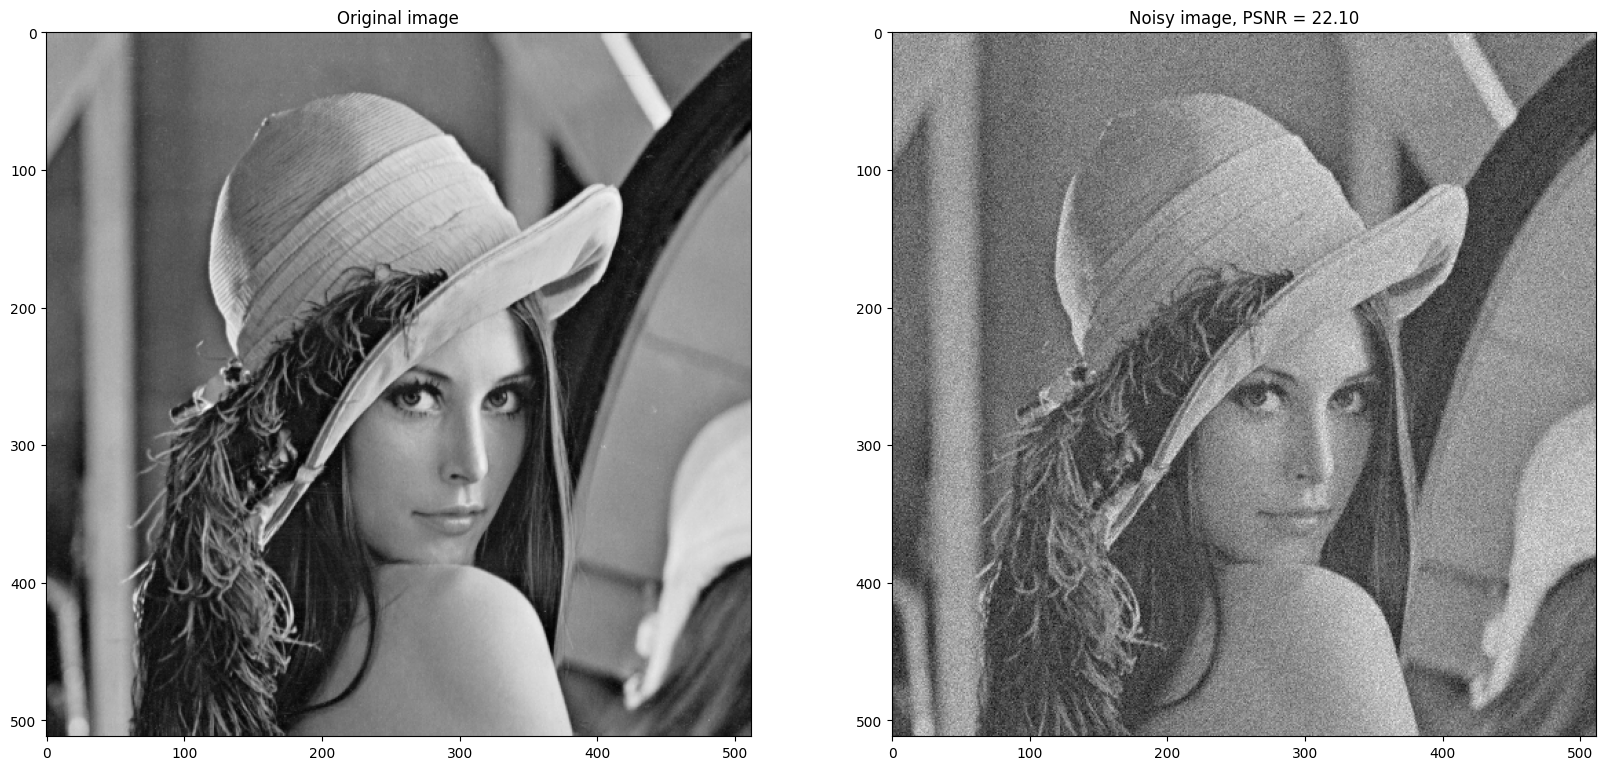

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')


Generate the Global PCA basis for this image
--------------------------------------------

Set the parameters for denoising

In [11]:
# set the threshold for the Hard Thresholding
tau = 3 * sigma_noise # Donoho says: sigma * sqrt(2*log(p^2))

Stack all the image patches in a large matrix $S$. Each patch goes in a column of $S$

In [12]:
S = np.zeros((p**2 ,int(imsz[0]-(p-1))**2 ))  

cnt = 0
for i in range(0, imsz[0]-p+1):
    for j in range(0, imsz[1]-p+1):
        # Taking the patch
        s = noisy_img[i:i+p, j:j+p]
        # Add into the big matrix
        S[:,cnt] = s.reshape(-1)
        cnt += 1

Compute $\tilde S$ by zero centering $S$


In [13]:
avg_patch = np.mean(S, axis = 0)
print(avg_patch.size)

Stilde = S - avg_patch

255025


Compute the PCA transformation via SVD


In [14]:
U, sigma, V = np.linalg.svd(Stilde@Stilde.T) 


In [15]:
V.shape

(64, 64)

Show the learned PCA basis

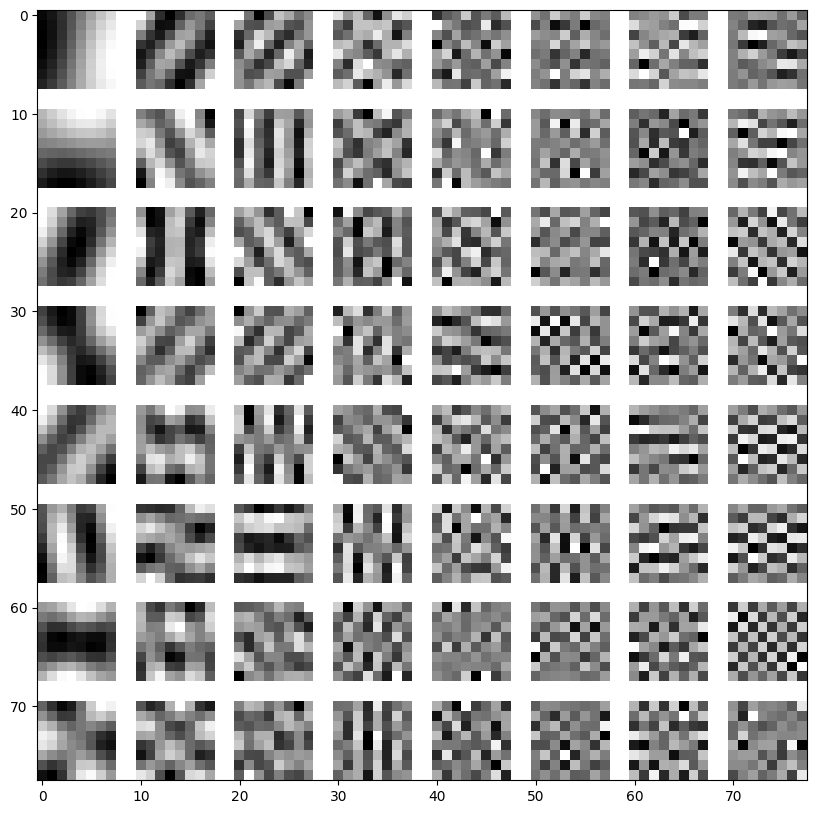

In [16]:
U_img = get_dictionary_img(U)
plt.figure(figsize=(10,10))
plt.imshow(U_img, cmap='gray')


Patch-based denoising
---------------------
Initialize the variables

In [17]:
STEP = 1
# initialize the estimated image
img_hat = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

In [18]:
cnt = 0
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i:i+p, j:j+p]

        # Preprocessing: remember to subtract the avg_patch (preprocessing used for PCA)
        s = s - avg_patch[cnt]

        # compute the representation w.r.t. the PCA basis
        x_hat = U.T @ s.reshape(-1)
        # perform the hard thresholding
        x_hat = x_hat * (np.abs(x_hat) > tau)
        # synthesis: perform the reconstruction
        y_hat = U @ x_hat

        # add the avg patch back
        y_hat = y_hat + avg_patch[cnt]

        # compute the weight for the reconstructed patch
        w = 1

        # put the denoised patch into the denoised image using the computed weight
        # UPDATE img_hat
        img_hat[i:i+p, j:j+p] += y_hat.reshape((p,p))  

        # store the weight of the current patch in the weight matrix
        # UPDATE weights
        weights[i:i+p, j:j+p] += w * np.ones((p,p))

        cnt += STEP
# normalize the estimated image with the computed weights
img_hat = img_hat / weights


Compute the psnr of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 32.15')

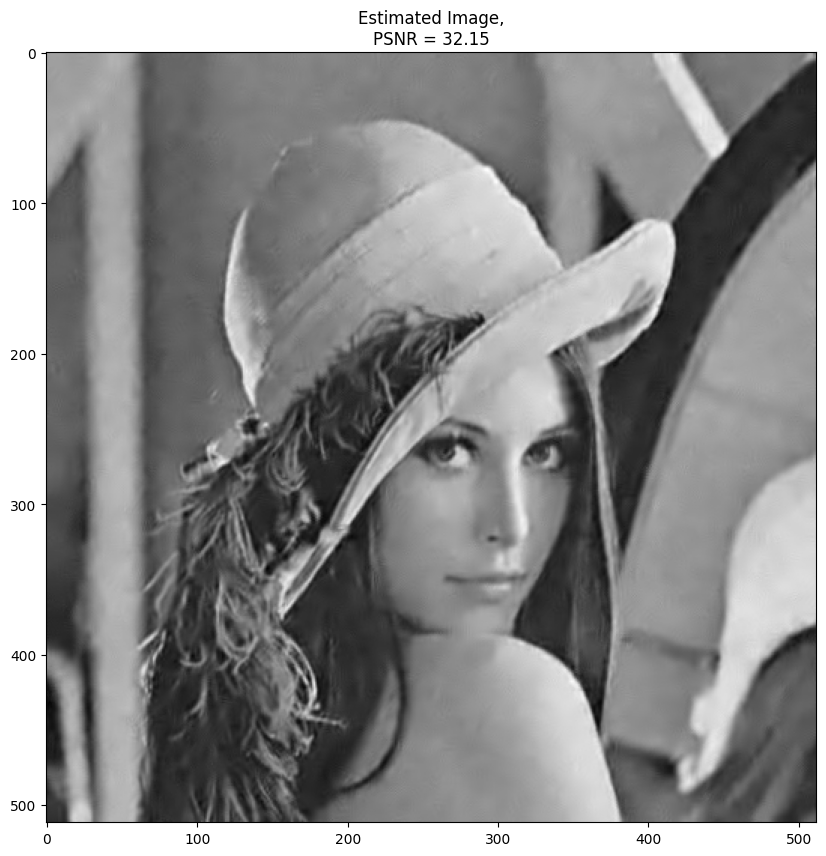

In [19]:
psnr_hat = 10 * np.log10(1/(np.mean((img - img_hat)**2)))
plt.figure(figsize=(10,10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')


# Only K component

In [45]:
# Find l
den = np.sum(np.square(sigma))
for i in range (0, M+1):
  num = np.sum(np.square(sigma[:i]))
  if num / den > 0.80: #ho cambiato il valore perchè con 0.8 trovava 41 e il psnr veniva circa 25
    l = i
    break

print(l,"/",M)

#Compute L first component
U_proj = U[:, :l]


3 / 64


In [46]:
STEP = 1
# initialize the estimated image
img_hat_proj = np.zeros_like(img)

# initialize the weight matrix
weights_proj = np.zeros_like(img)

In [47]:
cnt = 0
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i:i+p, j:j+p]

        # Preprocessing: remember to subtract the avg_patch (preprocessing used for PCA)
        s = s - avg_patch[cnt]

        # compute the representation w.r.t. the PCA basis
        x_hat = U_proj.T @ s.reshape(-1)
        # synthesis: perform the reconstruction
        y_hat = U_proj @ x_hat

        # add the avg patch back
        y_hat = y_hat + avg_patch[cnt]

        # compute the weight for the reconstructed patch
        w = 1

        # put the denoised patch into the denoised image using the computed weight
        # UPDATE img_hat
        img_hat_proj[i:i+p, j:j+p] += y_hat.reshape((p,p))  

        # store the weight of the current patch in the weight matrix
        # UPDATE weights
        weights_proj[i:i+p, j:j+p] += w * np.ones((p,p))

        cnt += STEP
# normalize the estimated image with the computed weights
img_hat_proj = img_hat_proj / weights_proj


Text(0.5, 1.0, 'Estimated Image,\nPSNR = 29.21')

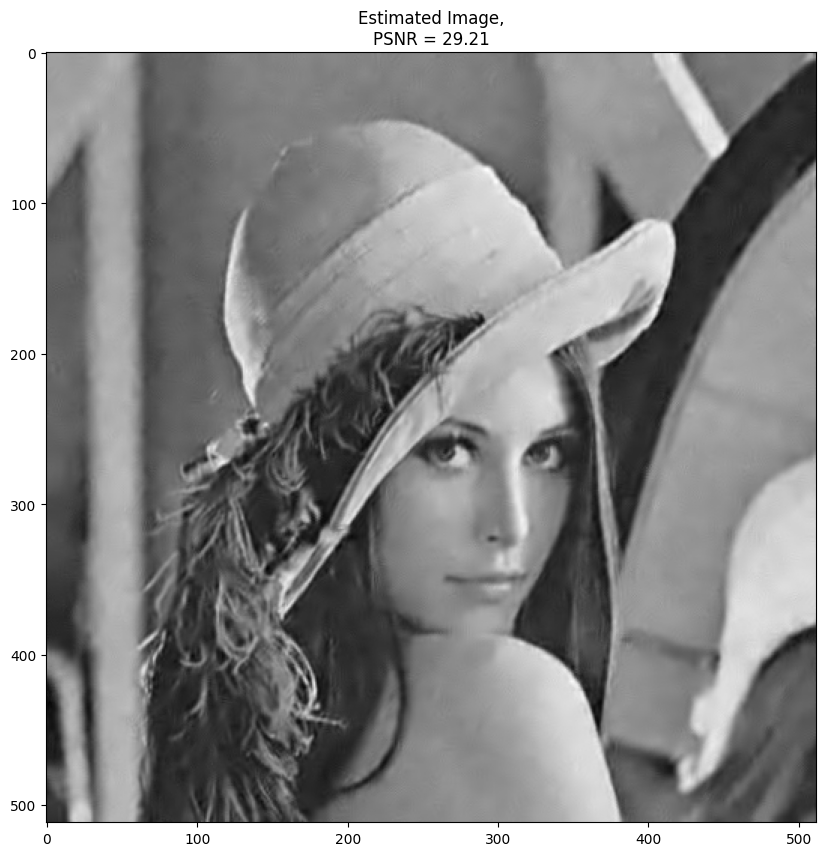

In [48]:
psnr_hat_proj = 10 * np.log10(1/(np.mean((img-img_hat_proj)**2)))
plt.figure(figsize=(10,10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat_proj:.2f}')


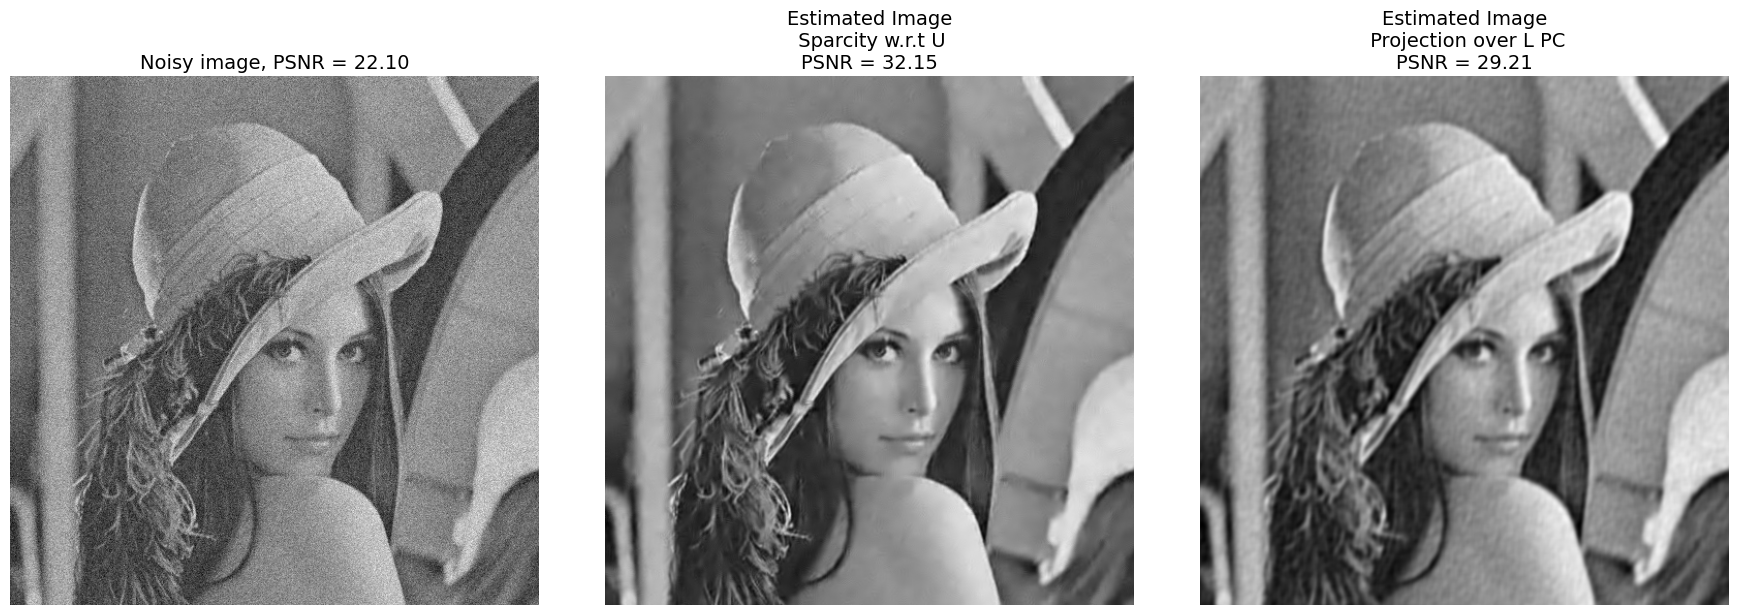

In [49]:
import matplotlib.pyplot as plt


images = [noisy_img, img_hat, img_hat_proj]
titles = [f'Noisy image, PSNR = {psnr_noisy:.2f}',
          f'Estimated Image\n Sparcity w.r.t U\nPSNR = {psnr_hat:.2f}',
          f'Estimated Image\n Projection over L PC\nPSNR = {psnr_hat_proj:.2f}']

# Inizializza una figura larga (18 di larghezza, 6 di altezza)
plt.figure(figsize=(18, 6))

# Primo subplot: 
plt.subplot(1, 3, 1)
plt.imshow(images[0], cmap='gray')
plt.title(titles[0], fontsize=14)
plt.axis('off')

# Secondo subplot: 
plt.subplot(1, 3, 2)
plt.imshow(images[1], cmap='gray')
plt.title(titles[1], fontsize=14)
plt.axis('off')

# Terzo subplot: 
plt.subplot(1, 3, 3)
plt.imshow(images[2], cmap='gray')
plt.title(titles[2], fontsize=14)
plt.axis('off')

# Ottimizza automaticamente lo spazio tra le foto per evitare che i titoli si sovrappongano
plt.tight_layout()
plt.show()
